# Employee Attrition Prediction
## Effect of Class Imbalance Handling Techniques on LR, KNN, and SVM
### IBM HR Analytics Dataset

## STEP 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, recall_score,
                              precision_score, f1_score,
                              roc_auc_score, matthews_corrcoef,
                              confusion_matrix, ConfusionMatrixDisplay)

from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

print('All libraries imported successfully')

All libraries imported successfully


## STEP 2: Load Dataset

In [3]:
# ---- CHANGE THIS PATH TO YOUR FILE LOCATION ----
df = pd.read_csv('C:\\Users\\hp\\Downloads\\Attrition\\WA_Fn-UseC_-HR-Employee-Attrition (3).csv')

print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (1470, 35)

First 5 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## STEP 3: Data Preprocessing

In [4]:
# Drop columns with no useful information
df = df.drop(['EmployeeCount', 'EmployeeNumber',
               'Over18', 'StandardHours'], axis=1)

# Check missing values
print('Missing Values:')
print(df.isnull().sum().sum(), 'total missing values')

# Encode all categorical (object) columns
# NOTE: we keep a SEPARATE encoder per column (not one reused LabelEncoder)
# so we can save them and reuse the exact same mapping in the Streamlit app.
encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

print('\nAfter Encoding - Dataset Shape:', df.shape)
print('\nData Types:')
print(df.dtypes.value_counts())


Missing Values:
0 total missing values

After Encoding - Dataset Shape: (1470, 31)

Data Types:
int64    31
Name: count, dtype: int64


## STEP 4: Exploratory Data Analysis (EDA)

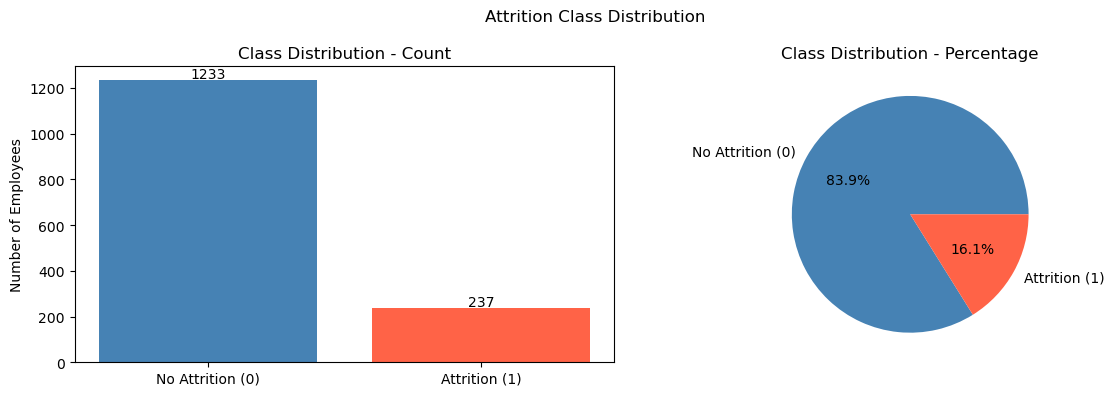

No Attrition: 1233
Attrition   : 237
Imbalance Ratio: 5.20:1


In [5]:
# ---- CLASS DISTRIBUTION ----
import matplotlib.pyplot as plt

counts = df['Attrition'].value_counts()
labels = ['No Attrition (0)', 'Attrition (1)']
colors = ['steelblue', 'tomato']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(labels, counts.values, color=colors)
axes[0].set_title('Class Distribution - Count')
axes[0].set_ylabel('Number of Employees')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center')

# Pie chart
axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%', colors=colors)
axes[1].set_title('Class Distribution - Percentage')

plt.suptitle('Attrition Class Distribution')
plt.tight_layout()
plt.show()

# Print summary
print(f'No Attrition: {counts[0]}')
print(f'Attrition   : {counts[1]}')
print(f'Imbalance Ratio: {counts[0]/counts[1]:.2f}:1')

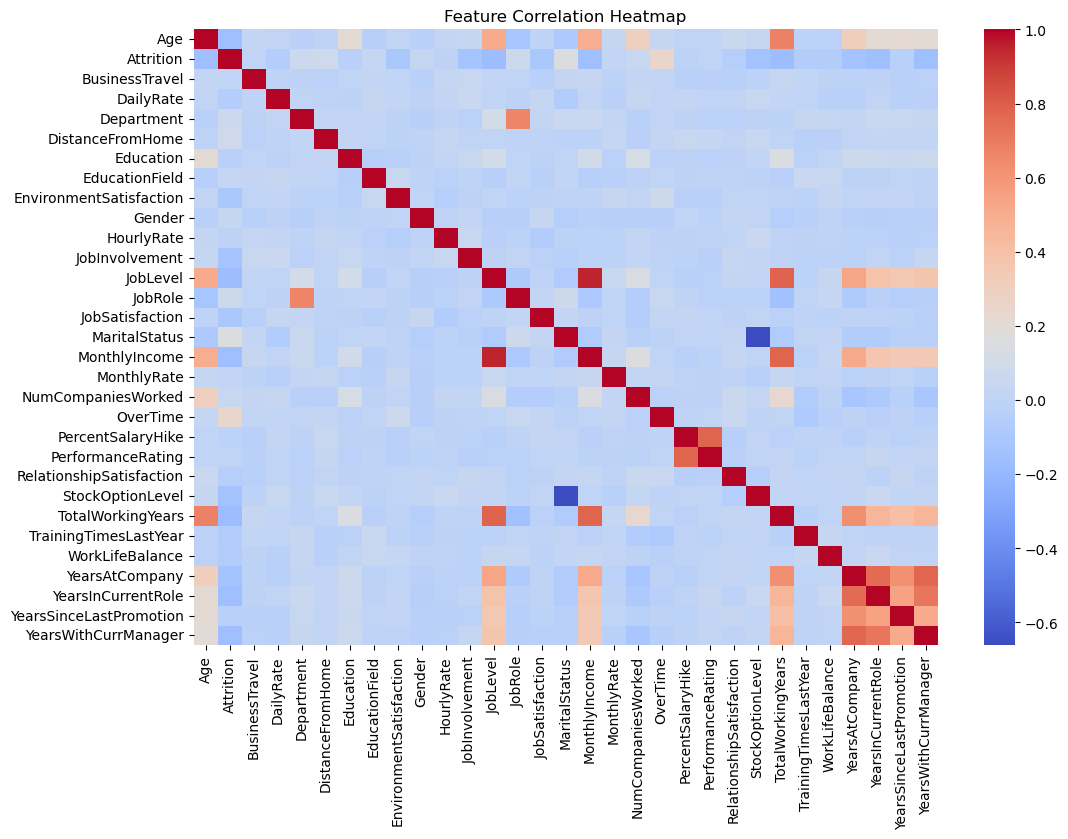

In [6]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [7]:
# Remove highly correlated features (threshold > 0.85)
X_temp = df.drop('Attrition', axis=1)
corr_matrix = X_temp.corr().abs()

# Keep only upper triangle to avoid duplicates
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find columns to drop
to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]

# Drop them
if to_drop:
    df = df.drop(columns=to_drop)
    print(f'Dropped: {to_drop}')
else:
    print('No features dropped')

Dropped: ['MonthlyIncome']


## STEP 5: Prepare Features and Target

In [8]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)
print('Number of features:', X.shape[1])

Feature matrix shape: (1470, 29)
Target shape: (1470,)
Number of features: 29


## STEP 6: Define Models and Sampling Techniques

In [9]:
# Define classifiers
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000,
                                               random_state=42),
    'KNN'                : KNeighborsClassifier(n_neighbors=5),
    'SVM'                : SVC(probability=True, random_state=42)
}

# Define sampling techniques
samplers = {
    'No Sampling'        : None,
    'Random Oversampling': RandomOverSampler(random_state=42),
    'SMOTE'              : SMOTE(random_state=42),
    'Random Undersampling': RandomUnderSampler(random_state=42)
}

print('Models defined      :', list(models.keys()))
print('Samplers defined    :', list(samplers.keys()))
print('Total experiments   :', len(models) * len(samplers))

Models defined      : ['Logistic Regression', 'KNN', 'SVM']
Samplers defined    : ['No Sampling', 'Random Oversampling', 'SMOTE', 'Random Undersampling']
Total experiments   : 12


## STEP 7: Run All Experiments with 10-Fold Stratified Cross Validation

In [10]:
results = []
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for sampler_name, sampler in samplers.items():
    for model_name, model in models.items():

        acc_list, rec_list, prec_list, f1_list, auc_list = [], [], [], [], []

        for train_idx, test_idx in skf.split(X, y):

            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test  = scaler.transform(X_test)

            if sampler:
                X_train, y_train = sampler.fit_resample(X_train, y_train)

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            y_prob = model.predict_proba(X_test)[:, 1]

            acc_list.append(accuracy_score(y_test, y_pred))
            prec_list.append(precision_score(y_test, y_pred, zero_division=0))
            rec_list.append(recall_score(y_test, y_pred, zero_division=0))
            f1_list.append(f1_score(y_test, y_pred, zero_division=0))
            auc_list.append(roc_auc_score(y_test, y_prob))

        results.append({
            'Sampling Technique': sampler_name,
            'Model'    : model_name,
            'Accuracy' : round(np.mean(acc_list),  4),
            'Precision': round(np.mean(prec_list), 4),
            'Recall'   : round(np.mean(rec_list),  4),
            'F1 Score' : round(np.mean(f1_list),   4),
            'AUC-ROC'  : round(np.mean(auc_list),  4),
        })

results_df = pd.DataFrame(results)

## STEP 8: Separate Output per Sampling Technique

In [11]:
# ============================================================
# HELPER: print table + bar chart for one sampling technique
# ============================================================
def show_sampling_output(technique_name):
    subset = results_df[results_df['Sampling Technique'] == technique_name].copy()
    subset = subset.drop('Sampling Technique', axis=1).reset_index(drop=True)

    print('=' * 70)
    print(f'  SAMPLING TECHNIQUE: {technique_name}')
    print('=' * 70)
    print(subset.to_string(index=False))
    print()

    # Bar chart for this technique
    metrics   = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']
    bar_colors = ['steelblue', 'tomato', 'green']
    x = np.arange(len(metrics))
    width = 0.25

    fig, ax = plt.subplots(figsize=(12, 5))
    for i, (model_name, color) in enumerate(zip(subset['Model'], bar_colors)):
        vals = [subset.loc[subset['Model'] == model_name, m].values[0] for m in metrics]
        ax.bar(x + i * width, vals, width, label=model_name, color=color)
        for j, v in enumerate(vals):
            ax.text(x[j] + i * width, v + 0.01, f'{v:.3f}', ha='center',
                    va='bottom', fontsize=8)

    ax.set_title(f'Model Performance — {technique_name}', fontsize=14, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score')
    ax.legend(title='Model')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


### 8.1 No Sampling (Baseline)

  SAMPLING TECHNIQUE: No Sampling
              Model  Accuracy  Precision  Recall  F1 Score  AUC-ROC
Logistic Regression    0.8660     0.6734  0.3380    0.4458   0.8182
                KNN    0.8456     0.6392  0.1270    0.2058   0.6815
                SVM    0.8599     0.7610  0.1862    0.2937   0.8214



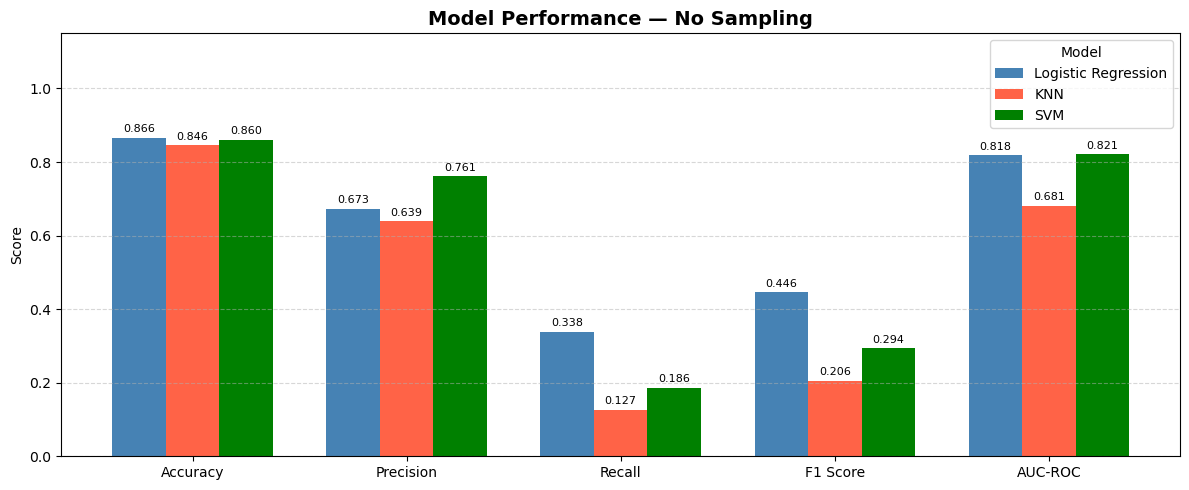

In [12]:
show_sampling_output('No Sampling')


### 8.2 Random Oversampling

  SAMPLING TECHNIQUE: Random Oversampling
              Model  Accuracy  Precision  Recall  F1 Score  AUC-ROC
Logistic Regression    0.7510     0.3657  0.7297    0.4857   0.8115
                KNN    0.7381     0.3087  0.4980    0.3780   0.6680
                SVM    0.8503     0.5318  0.5692    0.5480   0.8070



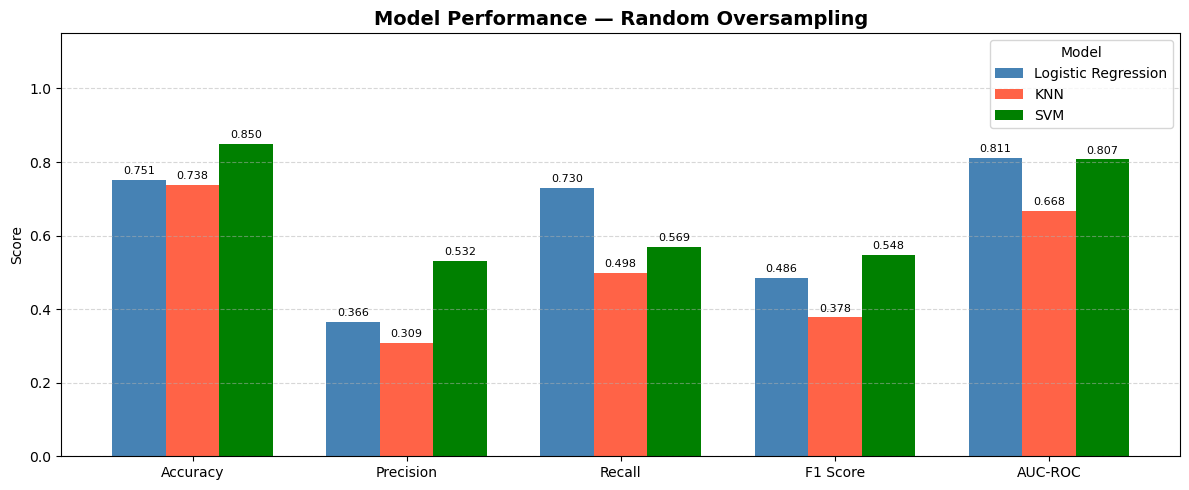

In [13]:
show_sampling_output('Random Oversampling')


### 8.3 SMOTE

  SAMPLING TECHNIQUE: SMOTE
              Model  Accuracy  Precision  Recall  F1 Score  AUC-ROC
Logistic Regression    0.7578     0.3715  0.7212    0.4892   0.8147
                KNN    0.6578     0.2641  0.6248    0.3700   0.6897
                SVM    0.8170     0.4434  0.4513    0.4417   0.7779



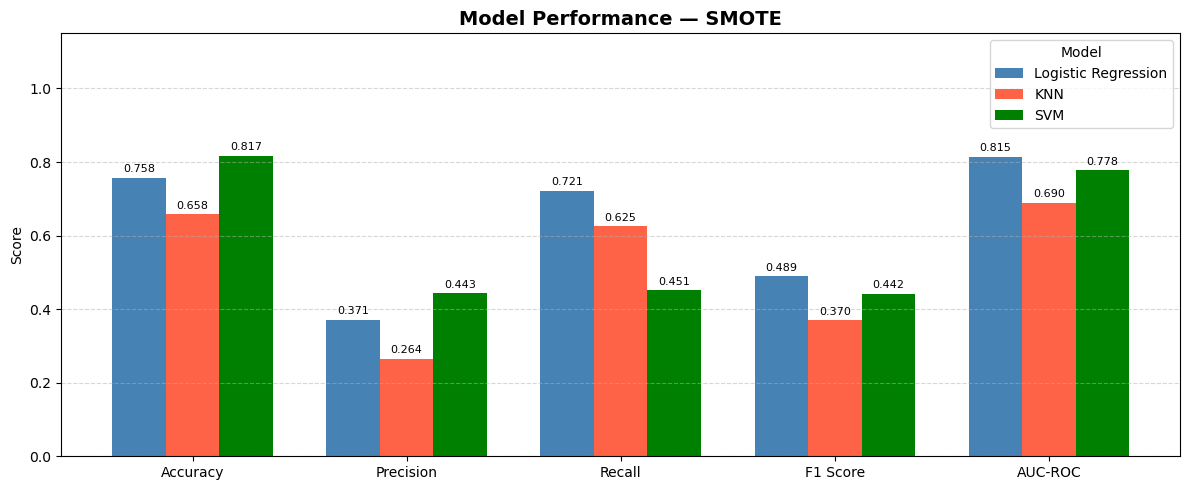

In [14]:
show_sampling_output('SMOTE')


### 8.4 Random Undersampling

  SAMPLING TECHNIQUE: Random Undersampling
              Model  Accuracy  Precision  Recall  F1 Score  AUC-ROC
Logistic Regression    0.7204     0.3347  0.7428    0.4608   0.8090
                KNN    0.7238     0.3244  0.6455    0.4303   0.7299
                SVM    0.7463     0.3592  0.7219    0.4785   0.8152



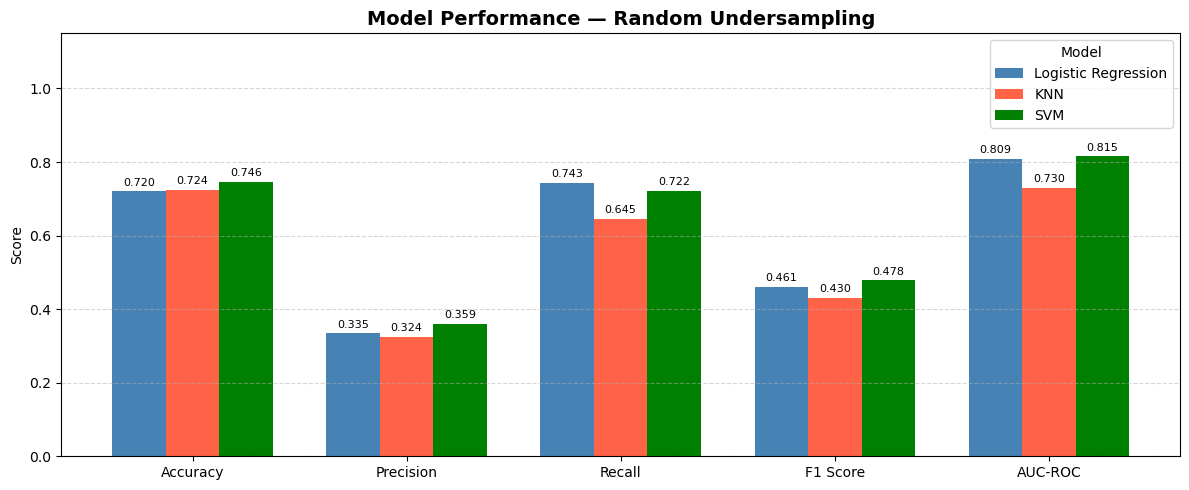

In [15]:
show_sampling_output('Random Undersampling')


## STEP 8: Results Table

In [16]:
# ---- RESULTS GROUPED BY SAMPLING TECHNIQUE ----
print('\n')
for technique in results_df['Sampling Technique'].unique():
    print('=' * 80)
    print(f'  SAMPLING TECHNIQUE: {technique}')
    print('=' * 80)
    subset = results_df[results_df['Sampling Technique'] == technique].copy()
    subset = subset.drop('Sampling Technique', axis=1)
    print(subset.to_string(index=False))
    print()



  SAMPLING TECHNIQUE: No Sampling
              Model  Accuracy  Precision  Recall  F1 Score  AUC-ROC
Logistic Regression    0.8660     0.6734  0.3380    0.4458   0.8182
                KNN    0.8456     0.6392  0.1270    0.2058   0.6815
                SVM    0.8599     0.7610  0.1862    0.2937   0.8214

  SAMPLING TECHNIQUE: Random Oversampling
              Model  Accuracy  Precision  Recall  F1 Score  AUC-ROC
Logistic Regression    0.7510     0.3657  0.7297    0.4857   0.8115
                KNN    0.7381     0.3087  0.4980    0.3780   0.6680
                SVM    0.8503     0.5318  0.5692    0.5480   0.8070

  SAMPLING TECHNIQUE: SMOTE
              Model  Accuracy  Precision  Recall  F1 Score  AUC-ROC
Logistic Regression    0.7578     0.3715  0.7212    0.4892   0.8147
                KNN    0.6578     0.2641  0.6248    0.3700   0.6897
                SVM    0.8170     0.4434  0.4513    0.4417   0.7779

  SAMPLING TECHNIQUE: Random Undersampling
              Model  Accuracy  P

In [17]:
# ---- BEST RESULT PER METRIC ----
print('\nBEST PERFORMING COMBINATION PER METRIC:')
print('-' * 60)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']:
    best_idx  = results_df[metric].idxmax()
    best_row  = results_df.loc[best_idx]
    print(f'{metric:12s}: {best_row["Sampling Technique"]:25s} '
          f'+ {best_row["Model"]:22s} = {best_row[metric]:.4f}')


BEST PERFORMING COMBINATION PER METRIC:
------------------------------------------------------------
Accuracy    : No Sampling               + Logistic Regression    = 0.8660
Precision   : No Sampling               + SVM                    = 0.7610
Recall      : Random Undersampling      + Logistic Regression    = 0.7428
F1 Score    : Random Oversampling       + SVM                    = 0.5480
AUC-ROC     : No Sampling               + SVM                    = 0.8214


## STEP 10: Top 5 Reasons for Employee Attrition

We use a **Logistic Regression model** (trained on the full dataset) to compute feature importance via coefficients. The top 5 features with the highest positive impact on attrition are identified as the **top reasons employees leave**. We then visualise each reason with a breakdown comparing employees who left vs stayed.

In [18]:
# ============================================================
# TOP 5 REASONS FOR ATTRITION
# Uses Logistic Regression coefficients as feature importance
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Train LR on full data to get feature importance ---
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

lr_importance = LogisticRegression(max_iter=1000, random_state=42)
lr_importance.fit(X_scaled, y)

# Get coefficients — positive = pushes toward Attrition
coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': lr_importance.coef_[0]
}).sort_values('Coefficient', ascending=False)

top5 = coef_df.head(5).reset_index(drop=True)

print('=' * 55)
print('  TOP 5 REASONS FOR EMPLOYEE ATTRITION')
print('=' * 55)
for i, row in top5.iterrows():
    print(f'  {i+1}. {row["Feature"]:30s}  (coef: {row["Coefficient"]:+.4f})')
print()
print('  A higher positive coefficient means that feature')
print('  strongly pushes the model toward predicting Attrition.')


  TOP 5 REASONS FOR EMPLOYEE ATTRITION
  1. OverTime                        (coef: +0.8058)
  2. YearsAtCompany                  (coef: +0.5218)
  3. YearsSinceLastPromotion         (coef: +0.4906)
  4. NumCompaniesWorked              (coef: +0.4162)
  5. Department                      (coef: +0.3954)

  A higher positive coefficient means that feature
  strongly pushes the model toward predicting Attrition.


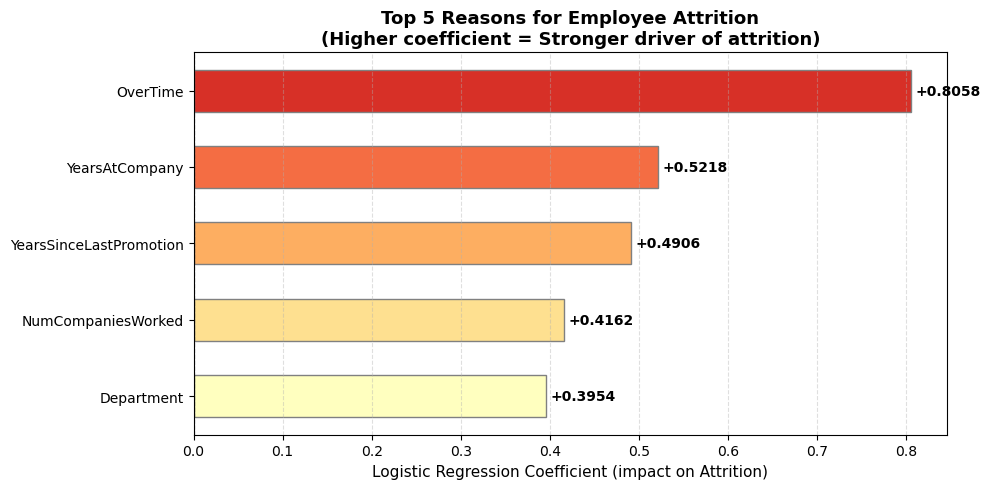

In [19]:
# ============================================================
# FEATURE IMPORTANCE BAR CHART — Top 5 Attrition Drivers
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#d73027', '#f46d43', '#fdae61', '#fee090', '#ffffbf']
bars = ax.barh(top5['Feature'][::-1], top5['Coefficient'][::-1],
               color=colors[::-1], edgecolor='grey', height=0.55)

for bar, val in zip(bars, top5['Coefficient'][::-1]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:+.4f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Logistic Regression Coefficient (impact on Attrition)', fontsize=11)
ax.set_title('Top 5 Reasons for Employee Attrition\n(Higher coefficient = Stronger driver of attrition)',
             fontsize=13, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


## STEP 9: Visualizations

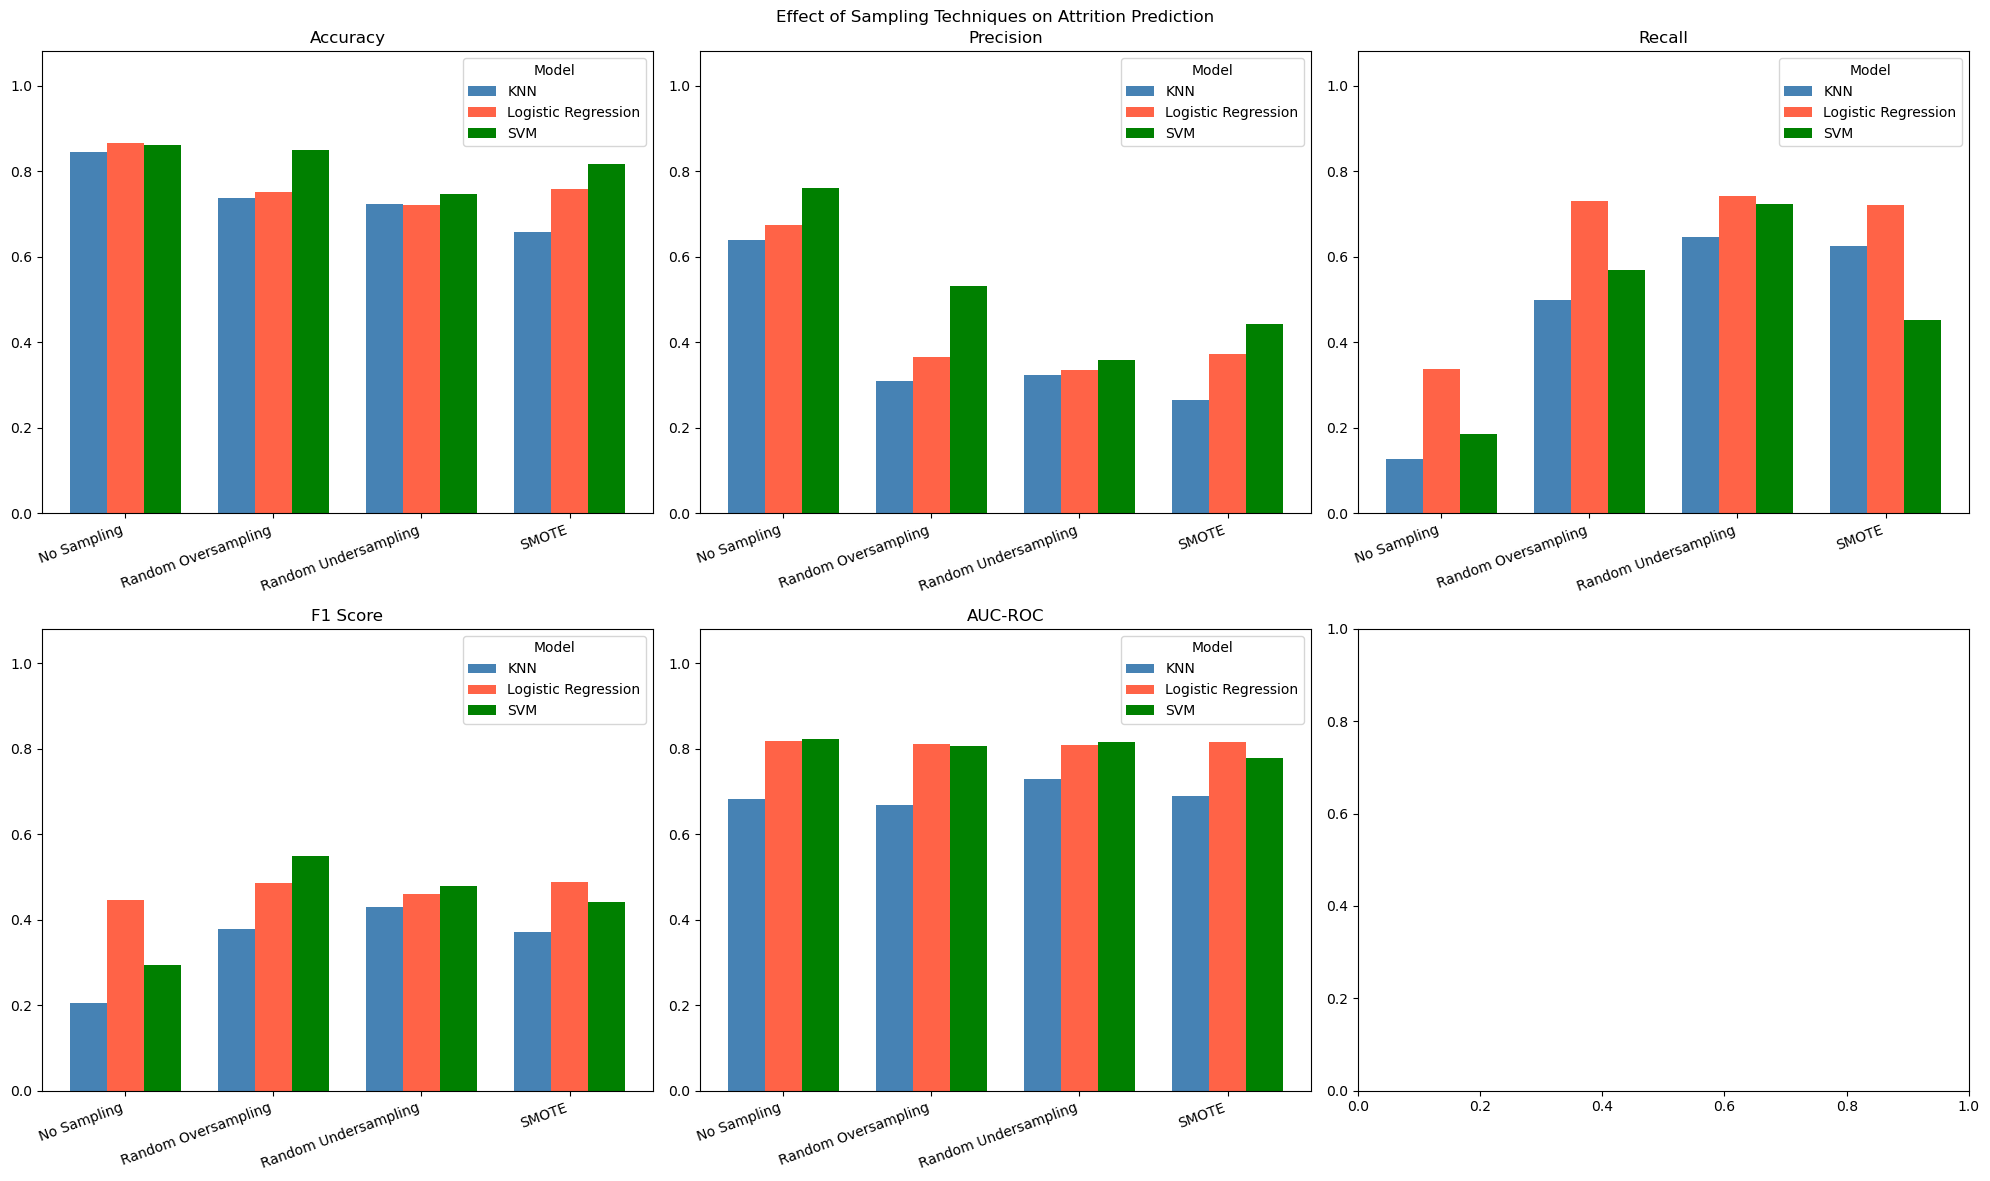

In [21]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']
colors  = ['steelblue', 'tomato', 'green']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    pivot = results_df.pivot(index='Sampling Technique', columns='Model', values=metric)
    x     = np.arange(len(pivot.index))

    for i, (col, color) in enumerate(zip(pivot.columns, colors)):
        axes[idx].bar(x + i * 0.25, pivot[col], width=0.25, label=col, color=color)

    axes[idx].set_title(metric)
    axes[idx].set_xticks(x + 0.25)
    axes[idx].set_xticklabels(pivot.index, rotation=20, ha='right')
    axes[idx].set_ylim(0, 1.08)
    axes[idx].legend(title='Model')

plt.suptitle('Effect of Sampling Techniques on Attrition Prediction')
plt.tight_layout()
plt.show()

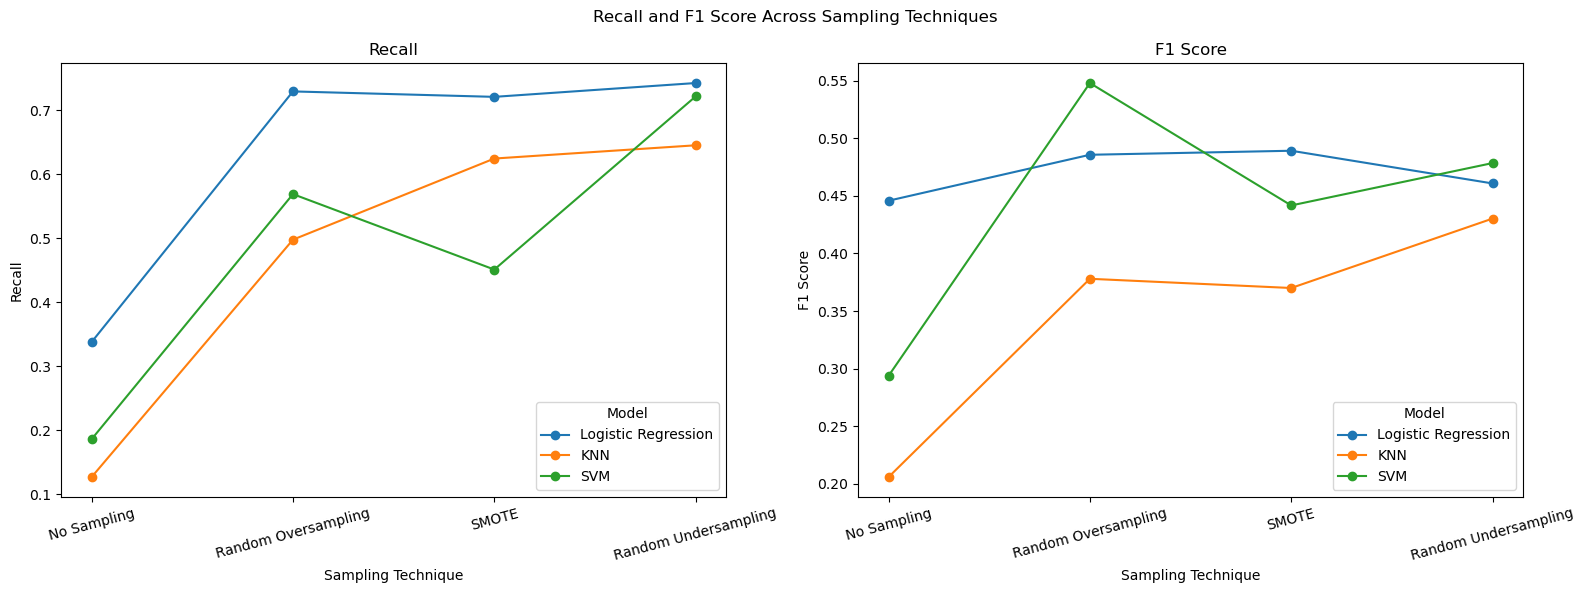

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, metric in enumerate(['Recall', 'F1 Score']):
    for model_name in results_df['Model'].unique():
        subset = results_df[results_df['Model'] == model_name]
        axes[idx].plot(subset['Sampling Technique'], subset[metric], marker='o', label=model_name)

    axes[idx].set_title(metric)
    axes[idx].set_xlabel('Sampling Technique')
    axes[idx].set_ylabel(metric)
    axes[idx].legend(title='Model')
    axes[idx].tick_params(axis='x', rotation=15)

plt.suptitle('Recall and F1 Score Across Sampling Techniques')
plt.tight_layout()
plt.show()

## STEP 11: Add XGBoost + Compare Against Best Sampler (for clean SHAP support)

LR/KNN/SVM don't have a fast, native SHAP explainer — KNN/SVM need the slow `KernelExplainer`. XGBoost gets an exact, fast `TreeExplainer`, and it typically beats LR/KNN/SVM on this dataset too. We add it as a 4th model using the sampling technique that performed best above, then use it as the model we explain and deploy.

In [23]:
from xgboost import XGBClassifier

# ---- Pick the best sampler from your STEP 8/9 results (edit if needed) ----
BEST_SAMPLER_NAME = 'SMOTE'          # change based on your results_df output
best_sampler = samplers[BEST_SAMPLER_NAME]

xgb_results = []
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

acc_list, rec_list, prec_list, f1_list, auc_list = [], [], [], [], []

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    if best_sampler is not None:
        X_train_s, y_train_r = best_sampler.fit_resample(X_train_s, y_train)
    else:
        y_train_r = y_train

    model = XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42
    )
    model.fit(X_train_s, y_train_r)
    preds = model.predict(X_test_s)
    probs = model.predict_proba(X_test_s)[:, 1]

    acc_list.append(accuracy_score(y_test, preds))
    rec_list.append(recall_score(y_test, preds))
    prec_list.append(precision_score(y_test, preds))
    f1_list.append(f1_score(y_test, preds))
    auc_list.append(roc_auc_score(y_test, probs))

print(f'XGBoost + {BEST_SAMPLER_NAME} (10-fold CV mean):')
print(f'  Accuracy : {sum(acc_list)/10:.4f}')
print(f'  Precision: {sum(prec_list)/10:.4f}')
print(f'  Recall   : {sum(rec_list)/10:.4f}')
print(f'  F1 Score : {sum(f1_list)/10:.4f}')
print(f'  AUC-ROC  : {sum(auc_list)/10:.4f}')
print('\nCompare these numbers to your results_df table above — if XGBoost wins, use it below.')


XGBoost + SMOTE (10-fold CV mean):
  Accuracy : 0.8619
  Precision: 0.6466
  Recall   : 0.3674
  F1 Score : 0.4619
  AUC-ROC  : 0.8197

Compare these numbers to your results_df table above — if XGBoost wins, use it below.


## STEP 12: Train Final Model on Full Data (for SHAP + deployment)

In [24]:
# Train the final scaler + model on the FULL dataset with the best sampler,
# so this exact object is what gets shipped to Streamlit.

final_scaler = StandardScaler()
X_scaled = final_scaler.fit_transform(X)

if best_sampler is not None:
    X_res, y_res = best_sampler.fit_resample(X_scaled, y)
else:
    X_res, y_res = X_scaled, y

final_model = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42
)
final_model.fit(X_res, y_res)

feature_names = list(X.columns)
print('Final model trained on', X_res.shape[0], 'rows,', len(feature_names), 'features.')


Final model trained on 2466 rows, 29 features.


## STEP 13: SHAP Explainability

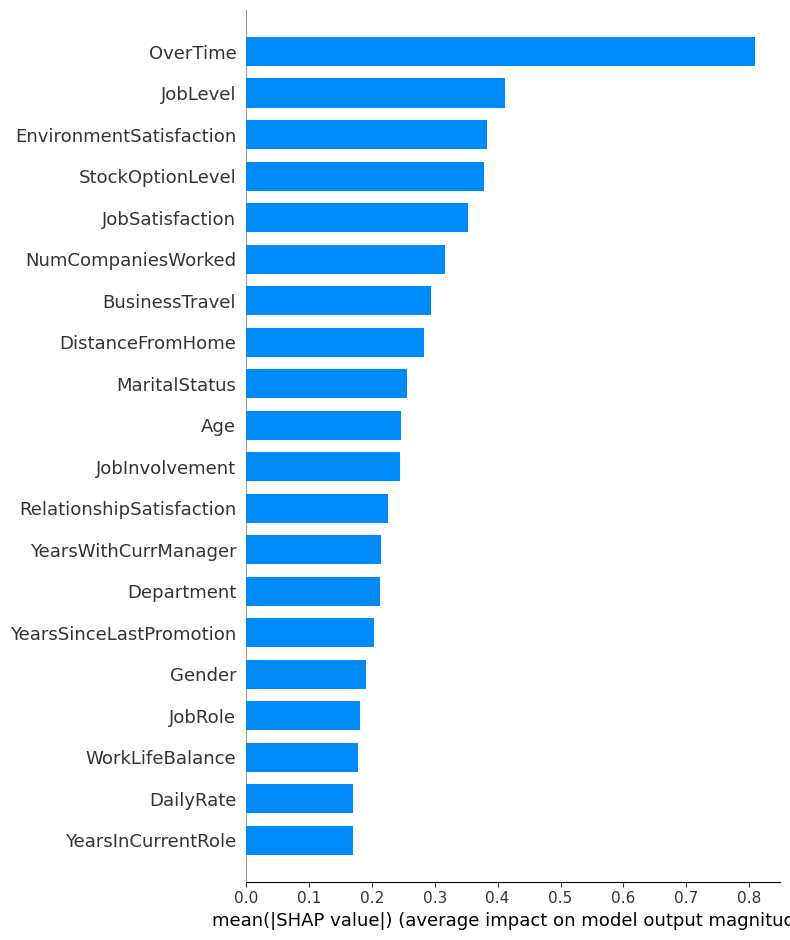

In [25]:
import shap

# TreeExplainer is exact + fast for tree models like XGBoost
explainer = shap.TreeExplainer(final_model)

# Use a sample of scaled X for global plots (full dataset is fine here, ~1400 rows)
shap_values = explainer.shap_values(X_scaled)

# ---- Global importance: which features drive attrition overall ----
shap.summary_plot(shap_values, X_scaled, feature_names=feature_names, plot_type='bar', show=True)


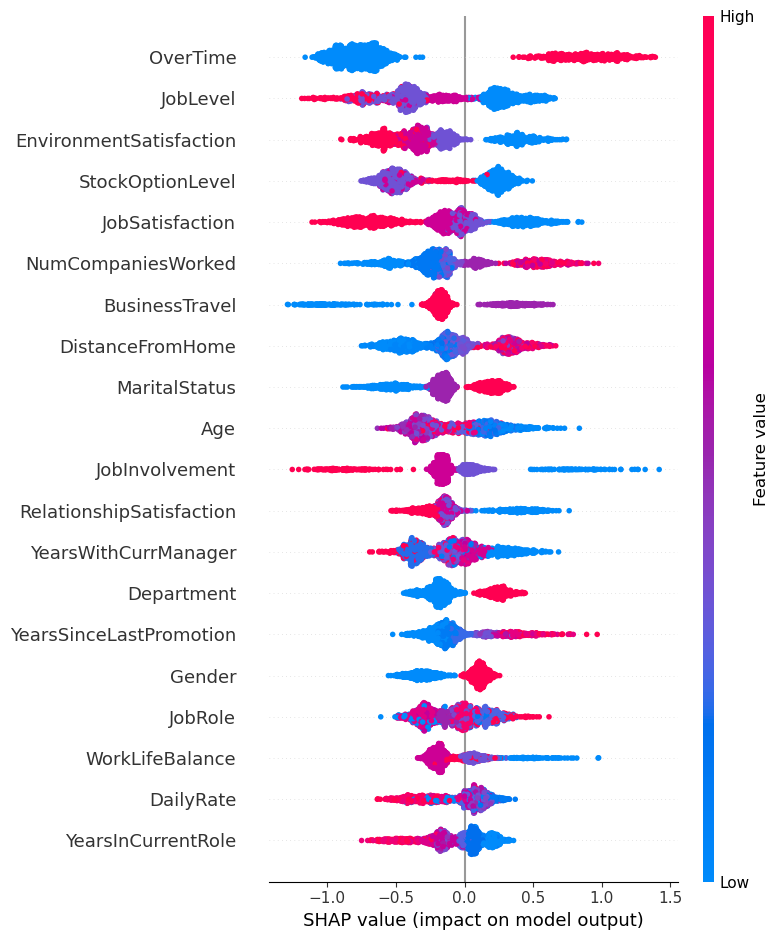

In [26]:
# ---- Beeswarm: direction + magnitude of each feature's effect ----
shap.summary_plot(shap_values, X_scaled, feature_names=feature_names, show=True)


Employee row 1060 — predicted attrition risk: 98.93%


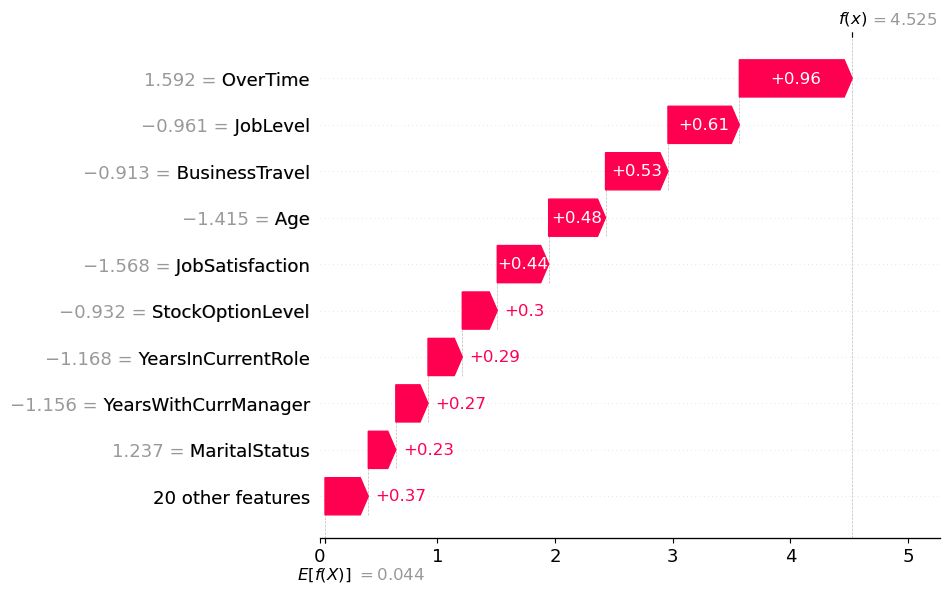

In [27]:
# ---- Individual explanation: why did the model flag THIS employee? ----
# Pick any row index to inspect (e.g. the employee with the highest predicted risk)
risk_scores = final_model.predict_proba(X_scaled)[:, 1]
highest_risk_idx = int(np.argmax(risk_scores))

print(f'Employee row {highest_risk_idx} — predicted attrition risk: {risk_scores[highest_risk_idx]:.2%}')

explanation = shap.Explanation(
    values=shap_values[highest_risk_idx],
    base_values=explainer.expected_value,
    data=X_scaled[highest_risk_idx],
    feature_names=feature_names
)
shap.plots.waterfall(explanation, show=True)


## STEP 14: Save Artifacts for the Streamlit App

In [28]:
import joblib

joblib.dump(final_model, 'attrition_model.pkl')
joblib.dump(final_scaler, 'attrition_scaler.pkl')
joblib.dump(encoders, 'attrition_encoders.pkl')      # per-column LabelEncoders from STEP 3
joblib.dump(feature_names, 'attrition_features.pkl')
joblib.dump(explainer, 'attrition_explainer.pkl')

# Also save a small reference sample (unscaled, decoded-friendly) for the dashboard's
# department-level heatmap in the Streamlit app
df.to_csv('attrition_reference.csv', index=False)

print('Saved: attrition_model.pkl, attrition_scaler.pkl, attrition_encoders.pkl,')
print('       attrition_features.pkl, attrition_explainer.pkl, attrition_reference.csv')
print('\nDownload all 6 files and put them in the same folder as app.py before deploying.')


Saved: attrition_model.pkl, attrition_scaler.pkl, attrition_encoders.pkl,
       attrition_features.pkl, attrition_explainer.pkl, attrition_reference.csv

Download all 6 files and put them in the same folder as app.py before deploying.
